# Laboratorio 4, Parte 2, avance de los ejercicios 1, 2 y 3

**CC3084, Data Science · Universidad del Valle de Guatemala · 2026**

Este cuaderno construye y audita el conjunto de datos para *Machine Learning*, define la respuesta binaria de alta presencia de cianobacteria y selecciona un conjunto de predictores sin fuga de información. Cada resultado numérico se obtiene de los 22 rásteres de la Parte I; no se descargan escenas nuevas.

> **Unidad de observación:** un píxel de agua válido de 10 × 10 m, asociado a lago, fecha, coordenadas UTM, bandas e índices.


## 0. Preparación del entorno


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def localizar_proyecto(inicio=None):
    inicio = Path(inicio or Path.cwd()).resolve()
    for candidato in [inicio, *inicio.parents]:
        if candidato.name == "l04_analisis_geoespacial" and (candidato / "data").exists():
            return candidato
        anidado = candidato / "l04_analisis_geoespacial"
        if (anidado / "data").exists():
            return anidado
    raise FileNotFoundError("No se encontró l04_analisis_geoespacial.")


PROJECT_DIR = localizar_proyecto()
SRC_DIR = PROJECT_DIR / "parte_2" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from preparar_ml import (
    CRS_ANALISIS,
    PREDICTORES_BASE,
    UMBRAL_ALERTA_CHL,
    VARIABLES_PROHIBIDAS,
    auditar_predictores,
    ejecutar_pipeline,
    inventariar_escenas,
)

OUTPUT_DIR = PROJECT_DIR / "parte_2" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

resultado = ejecutar_pipeline(PROJECT_DIR, reutilizar=True)
manifest = resultado["manifest"]
print(f"Proyecto: {PROJECT_DIR}")
print(f"Dataset: {resultado['dataset_dir']}")
print(f"Versión del pipeline: {manifest['pipeline_version']}")


Proyecto: C:\Users\richi\Documents\2026_S2_Local\Data_Science\Data-Science\l04_analisis_geoespacial
Dataset: C:\Users\richi\Documents\2026_S2_Local\Data_Science\Data-Science\l04_analisis_geoespacial\parte_2\data\processed\dataset_ml
Versión del pipeline: 4


# 1. Preparación de los datos para Machine Learning

## 1.1 Integridad de fuentes y unidad de observación

Se exigen exactamente 22 escenas oficiales (11 por lago). Para cada fecha deben existir y estar alineados: el GeoTIFF de nueve bandas, NDVI, NDWI y clorofila-a/cianobacteria. La validación comprueba CRS, transformación, dimensiones, resolución y orden de bandas antes de combinar cualquier píxel.

El dataset se guarda como **Parquet particionado por lago y fecha**, lo cual permite conservar todos los píxeles válidos sin cargar más de 13 millones de filas simultáneamente en memoria.


In [3]:
inventario = inventariar_escenas(PROJECT_DIR)
assert len(inventario) == 22
assert inventario["crs"].eq(CRS_ANALISIS).all()
assert inventario["resolucion_m"].eq(10).all()

display(
    inventario.groupby("lago").agg(
        escenas=("fecha", "count"),
        primera_fecha=("fecha", "min"),
        ultima_fecha=("fecha", "max"),
        alto=("alto", "first"),
        ancho=("ancho", "first"),
    )
)
print("Validación superada: 22 escenas y cuatro fuentes alineadas por escena.")


,escenas,primera_fecha,ultima_fecha,alto,ancho
lago,,,,,
amatitlan,11,2025-01-28,2026-06-19,917,1360
atitlan,11,2025-01-18,2026-07-22,1751,2759


Validación superada: 22 escenas y cuatro fuentes alineadas por escena.


## 1.2 Variables incluidas

Las nueve bandas se leen como reflectancia escalada (`DN / 10000`). Se conservan NDVI, NDWI y la estimación continua de clorofila-a, aunque varias de estas columnas se excluirán de los predictores por fuga de información. Las coordenadas están en **WGS 84 / UTM zona 15N (EPSG:32615)** y expresadas en metros.


In [4]:
resumen_variables = pd.read_csv(resultado["variables"])
catalogo = pd.read_csv(resultado["catalogo"])
display(resumen_variables)


,variable,tipo_dato,valores_faltantes,pct_faltantes,observaciones_evaluadas,descripcion,familia
0,lago,object,0,0.0,13689403,Identificador del lago,espacial/categórica
1,fecha,datetime64[s],0,0.0,13689403,Fecha de adquisición,temporal/identificador
2,fila,int32,0,0.0,13689403,Fila del píxel en el ráster,identificador
3,columna,int32,0,0.0,13689403,Columna del píxel en el ráster,identificador
4,x_utm,float32,0,0.0,13689403,Coordenada este en EPSG:32615 (m),espacial
5,y_utm,float32,0,0.0,13689403,Coordenada norte en EPSG:32615 (m),espacial
6,b02,float32,0,0.0,13689403,Reflectancia azul Sentinel-2,banda espectral
7,b03,float32,0,0.0,13689403,Reflectancia verde Sentinel-2,banda espectral
8,b04,float32,0,0.0,13689403,Reflectancia roja Sentinel-2,banda espectral
9,b05,float32,0,0.0,13689403,Reflectancia red-edge 1 Sentinel-2,banda espectral


## 1.3 Limpieza y control de calidad

Se aplican, en este orden, los siguientes criterios:

1. **Límite del lago:** como la Parte I no incluye un polígono oficial, se aproxima el cuerpo de agua mediante persistencia multitemporal: el píxel debe haber sido clasificado como agua en al menos 3 de las 11 fechas del lago.
2. **Máscara válida de la Parte I:** la clorofila-a debe ser finita; esto elimina tierra y áreas que el flujo CyanoLakes no reconoció como agua en esa fecha.
3. **NoData:** todas las bandas requeridas deben tener dato.
4. **Valores físicamente plausibles:** se admite el intervalo amplio `[-0.1, 1.2]`; reflectancias L2A ligeramente negativas pueden aparecer tras la corrección atmosférica sobre agua oscura y no se confunden con NoData.
5. **Índices válidos:** NDVI y NDWI deben ser finitos y pertenecer a `[-1, 1]`.
6. **Nubes:** ninguna escena supera 20 % de nubosidad y se retiran píxeles simultáneamente brillantes en visible y SWIR. La ausencia de SCL impide afirmar una máscara de nubes perfecta; esta limitación debe mantenerse en el informe.

No se usa un filtro de desviaciones estándar: podría eliminar precisamente los extremos espectrales de una floración real.


In [5]:
limpieza = pd.read_csv(resultado["limpieza"])
columnas_limpieza = [
    "lago", "fecha", "pixeles_totales_bbox", "pixeles_objetivo_valido",
    "descartados_nodata_bandas", "descartados_reflectancia",
    "descartados_indices", "descartados_nube_brilante",
    "observaciones_validas", "pct_conservado_bbox",
]
display(limpieza[columnas_limpieza])
assert (limpieza["observaciones_validas"] > 0).all()


,lago,fecha,pixeles_totales_bbox,pixeles_objetivo_valido,descartados_nodata_bandas,descartados_reflectancia,descartados_indices,descartados_nube_brilante,observaciones_validas,pct_conservado_bbox
0,amatitlan,2025-01-28,1247120,147442,13,0,4695,6,141852,11.374367
1,amatitlan,2025-04-15,1247120,144535,0,0,272,4,144251,11.566730
2,amatitlan,2025-04-28,1247120,144731,0,0,0,8,144700,11.602733
3,amatitlan,2025-11-24,1247120,147330,6,0,3025,21,143545,11.510119
4,amatitlan,2026-01-08,1247120,148399,0,0,761,20,146461,11.743938
5,amatitlan,2026-02-02,1247120,145496,0,0,31,19,145437,11.661829
6,amatitlan,2026-02-07,1247120,146746,69328,0,12185,0,65188,5.227083
7,amatitlan,2026-03-29,1247120,146463,0,0,105,10,146330,11.733434
8,amatitlan,2026-04-13,1247120,147301,0,0,148,12,147070,11.792771
9,amatitlan,2026-04-28,1247120,141031,0,0,0,7,139628,11.196036


## 1.4 Tamaño, observaciones por lago/fecha y valores faltantes


In [6]:
resumen_lago = pd.read_csv(resultado["lago"])
resumen_fecha = pd.read_csv(resultado["lago_fecha"], parse_dates=["fecha"])

print(f"Observaciones totales: {manifest['observaciones_totales']:,}")
display(resumen_lago)
display(resumen_fecha)

assert resumen_fecha["observaciones_validas"].sum() == manifest["observaciones_totales"]
assert resumen_variables["pct_faltantes"].eq(0).all()
print("Porcentaje de valores faltantes después de la limpieza: 0 % en todas las variables.")


Observaciones totales: 13,689,403


,lago,observaciones_validas,n_clase_0,n_clase_1,pct_clase_1
0,amatitlan,1500358,1365448,134910,8.991854
1,atitlan,12189045,12186247,2798,0.022955


,lago,fecha,observaciones_validas,n_clase_0,n_clase_1,pct_clase_1
0,amatitlan,2025-01-28,141852,141818,34,0.023969
1,amatitlan,2025-04-15,144251,143864,387,0.268282
2,amatitlan,2025-04-28,144700,138307,6393,4.418106
3,amatitlan,2025-11-24,143545,140981,2564,1.786199
4,amatitlan,2026-01-08,146461,137800,8661,5.913520
5,amatitlan,2026-02-02,145437,145410,27,0.018565
6,amatitlan,2026-02-07,65188,65187,1,0.001534
7,amatitlan,2026-03-29,146330,136654,9676,6.612451
8,amatitlan,2026-04-13,147070,145008,2062,1.402053
9,amatitlan,2026-04-28,139628,95701,43927,31.460022


Porcentaje de valores faltantes después de la limpieza: 0 % en todas las variables.


## 1.5 Análisis exploratorio

Los conteos y porcentajes de la respuesta se calculan sobre **todo** el dataset. Para gráficos multivariados se usa una muestra reproducible de hasta 10,000 píxeles por escena (220,000 filas como máximo), de modo que ninguna fecha grande monopolice las visualizaciones. Esta muestra no reemplaza los conteos exactos.


Tamaño de la muestra EDA: 220,000


,count,mean,std,min,25%,50%,75%,max
b07,220000.0,1.995185e-02,0.024127,-1.640000e-02,5.100000e-03,1.110000e-02,2.750000e-02,5.659000e-01
b8a,220000.0,1.583317e-02,0.019239,-1.890000e-02,3.700000e-03,9.300000e-03,2.270000e-02,5.338000e-01
x_utm,220000.0,7.283924e+05,34228.878906,6.810650e+05,6.942850e+05,7.325800e+05,7.627350e+05,7.670650e+05
y_utm,220000.0,1.612519e+06,13287.069336,1.594635e+06,1.598875e+06,1.608885e+06,1.625775e+06,1.631555e+06
sin_dia_anio,220000.0,4.729931e-01,0.534598,-6.354321e-01,1.372788e-01,6.414603e-01,9.721182e-01,9.984354e-01
cos_dia_anio,220000.0,1.030973e-01,0.692717,-9.769385e-01,-4.443783e-01,-7.248685e-02,8.039280e-01,9.994074e-01
dias_desde_inicio,220000.0,3.095909e+02,168.332214,0.000000e+00,1.150000e+02,3.675000e+02,4.500000e+02,5.500000e+02
alta_cyano,220000.0,4.455000e-02,0.206314,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


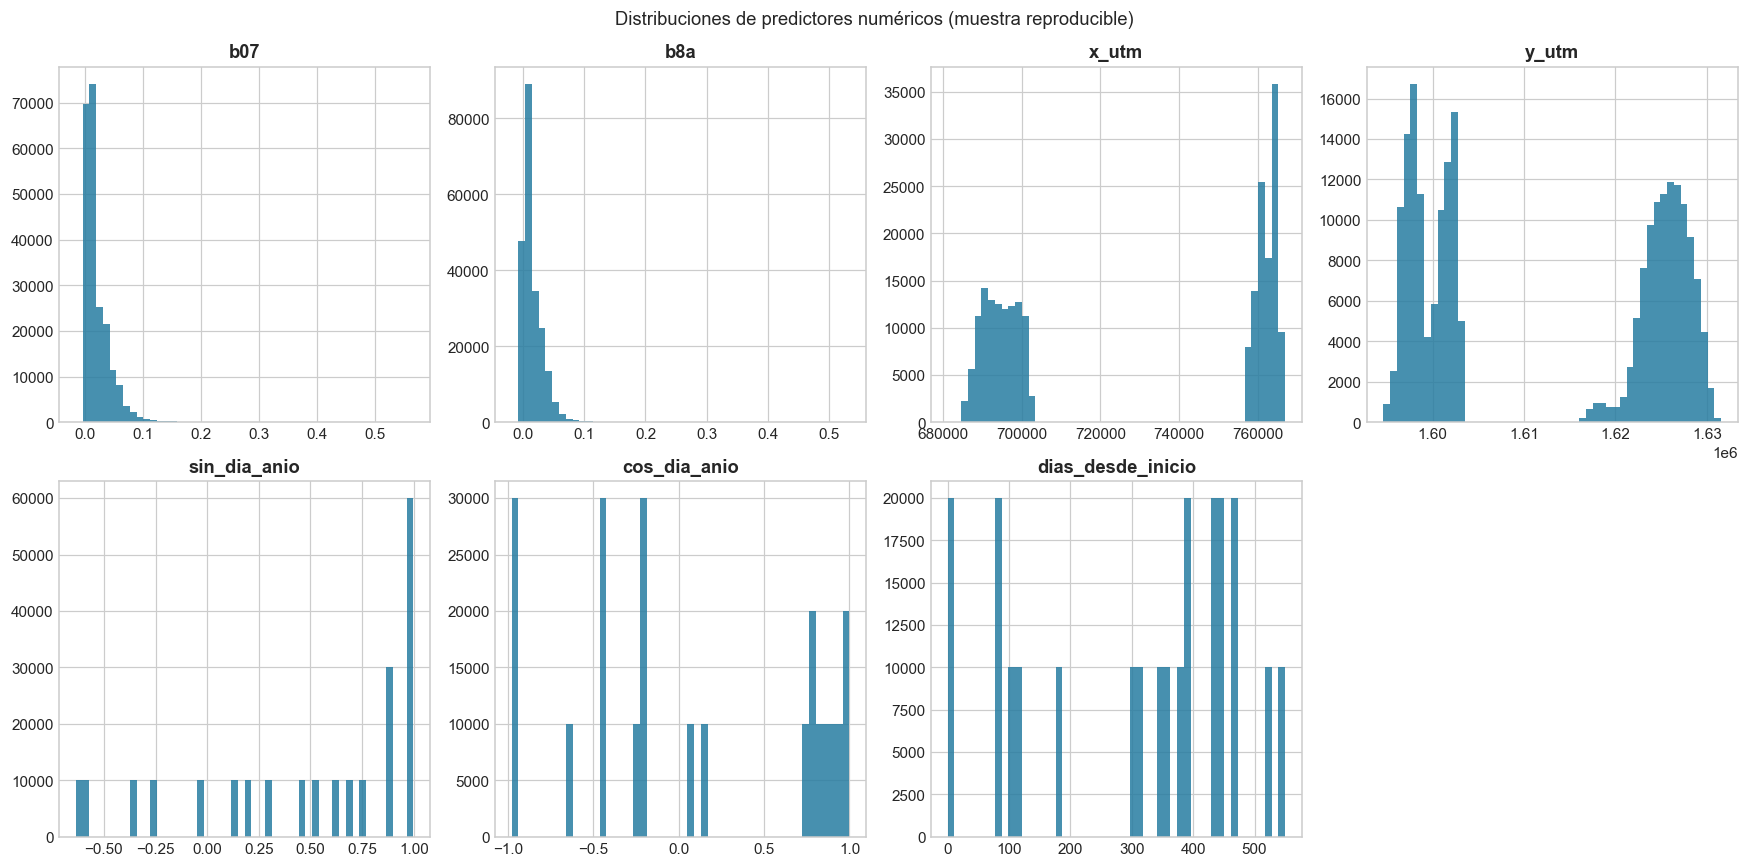

In [7]:
muestra = pd.read_parquet(resultado["muestra"])
print(f"Tamaño de la muestra EDA: {len(muestra):,}")

variables_eda = ["b07", "b8a", "x_utm", "y_utm", "sin_dia_anio", "cos_dia_anio", "dias_desde_inicio"]
display(muestra[variables_eda + ["alta_cyano"]].describe().T)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, variable in zip(axes.flat, variables_eda):
    ax.hist(muestra[variable], bins=50, color="#277DA1", alpha=0.85)
    ax.set_title(variable)
axes.flat[-1].axis("off")
fig.suptitle("Distribuciones de predictores numéricos (muestra reproducible)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_distribuciones_predictores.png", dpi=180, bbox_inches="tight")
plt.show()


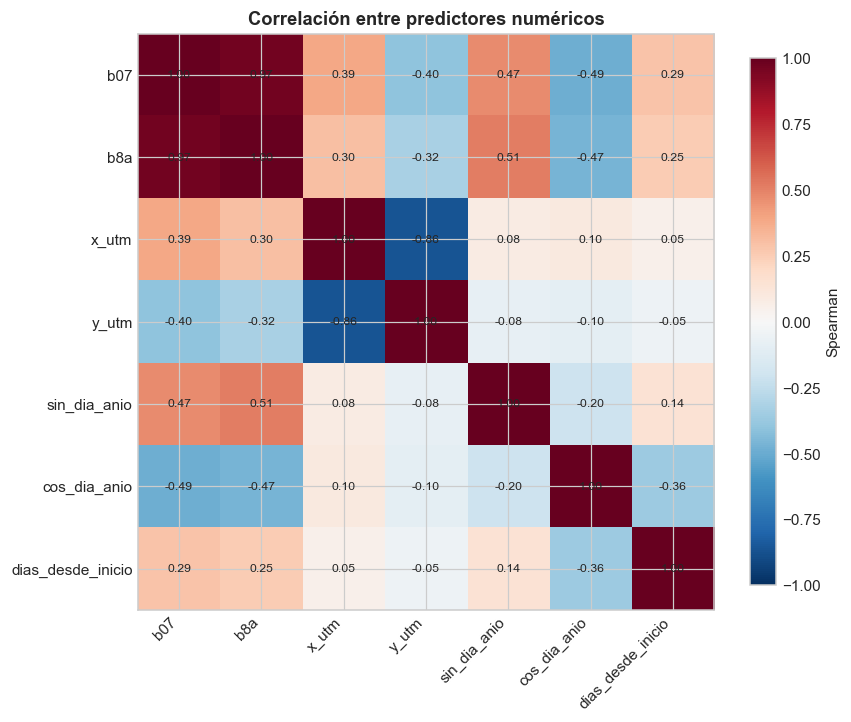

Pares con |rho| >= 0.90: [('b07', 'b8a', np.float64(0.9656785727337587))]


In [8]:
correlacion = muestra[variables_eda].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 7))
imagen = ax.imshow(correlacion, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(correlacion)), correlacion.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlacion)), correlacion.columns)
for i in range(len(correlacion)):
    for j in range(len(correlacion)):
        ax.text(j, i, f"{correlacion.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(imagen, ax=ax, shrink=0.8, label="Spearman")
ax.set_title("Correlación entre predictores numéricos")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_correlacion_predictores.png", dpi=180, bbox_inches="tight")
plt.show()

alta_correlacion = [
    (a, b, correlacion.loc[a, b])
    for i, a in enumerate(correlacion.columns)
    for b in correlacion.columns[i + 1:]
    if abs(correlacion.loc[a, b]) >= 0.90
]
print("Pares con |rho| >= 0.90:", alta_correlacion or "ninguno")


**Interpretación.** `b07` y `b8a` están fuertemente sesgadas hacia valores bajos (reflectancia típica de agua oscura), con una cola larga hacia valores altos, esa cola es precisamente donde se concentra la señal de biomasa elevada que interesa detectar. `x_utm`/`y_utm` son claramente bimodales porque describen dos lagos geográficamente separados, no una variable continua con dos modos reales. `sin_dia_anio`, `cos_dia_anio` y `dias_desde_inicio` se ven "escalonadas" en vez de continuas: solo hay 11 fechas oficiales por lago, así que cada barra corresponde a una fecha concreta repetida en miles de píxeles, no a una muestra densa del calendario, la misma limitación que ya advertía el reporte principal sobre no poder establecer una estacionalidad definitiva con tan pocas observaciones.

La matriz de correlación confirma tres cosas: (1) `b07` y `b8a` están altamente correlacionadas entre sí (ρ≈0.97, por encima del umbral de aviso de 0.90 que marca el propio código), redundancia esperada entre bandas adyacentes del espectro; (2) ambas bandas correlacionan moderadamente con `sin_dia_anio`/`cos_dia_anio` (ρ≈0.47–0.51), como las 11 fechas no cubren el calendario de forma uniforme, parte de lo que luce como señal estacional puede estar entrelazado con las condiciones particulares de esas fechas específicas, así que esa relación debe leerse con cautela; y (3) `x_utm`/`y_utm` están fuertemente correlacionadas entre sí por la orientación de los lagos, pero eso no es multicolinealidad problemática porque `lago` ya captura explícitamente a cuál cuerpo de agua pertenece cada píxel.


## 1.6 Decisiones principales

- Se conserva la resolución nativa de 10 m porque el objetivo del laboratorio es modelar zonas dentro del lago, no promedios por escena.
- El límite persistente reduce falsos positivos aislados sin requerir descargar una geometría nueva; aun así, una futura versión debería usar polígonos oficiales.
- No se imputan bandas, índices ni etiqueta. Imputar la respuesta inventaría presencia/ausencia y la interpolación espacial de reflectancia podría suavizar una floración.
- La clorofila-a negativa se trunca a cero: una concentración negativa no tiene interpretación física y no afecta el corte alto de 12 µg/L.
- Parquet conserva tipos y comprime el dataset; el particionamiento permite lectura selectiva por lago/fecha.


# 2. Construcción de la variable respuesta

## 2.1–2.2 Definición binaria y punto de corte

Se define `alta_cyano = 0` para `chl_cyano < 12 µg/L` y `alta_cyano = 1` para `chl_cyano ≥ 12 µg/L`.

La **OMS (2021)** establece, para aguas recreativas dulces con dominancia de cianobacterias, un nivel de vigilancia de **1–12 µg/L de clorofila-a** y un nivel de alerta 1 de **12–24 µg/L**. Por eso 12 µg/L es un punto de corte operativo y científicamente defendible entre biomasa baja/vigilancia y presencia elevada que amerita gestión. El nivel de alerta 2 depende de *scum* o transparencia menor de 0.5–1 m; no puede deducirse únicamente de este ráster.

La etiqueta no confirma toxicidad: la clorofila-a estimada por NDCI es un indicador de biomasa, no un recuento celular, biovolumen o medición de cianotoxinas. Un positivo debe interpretarse como prioridad para verificación de campo.

**Bibliografía científica y normativa**

- World Health Organization. (2021). *Guidelines on recreational water quality. Volume 1: Coastal and fresh waters*. ISBN 978-92-4-003130-2. https://www.who.int/publications/b/58742
- World Health Organization. (2021). *Compendium of WHO and other UN guidance on health and environment*, tabla 3.2. https://cdn.who.int/media/docs/default-source/who-compendium-on-health-and-environment/who_compendium_chapter3_27082021_pdf.pdf
- Mishra, S., & Mishra, D. R. (2012). Normalized difference chlorophyll index: A novel model for remote estimation of chlorophyll-a concentration in turbid productive waters. *Remote Sensing of Environment, 117*, 394–406. https://doi.org/10.1016/j.rse.2011.10.016


In [9]:
print(f"Umbral operativo: {UMBRAL_ALERTA_CHL:g} µg/L")
print("0 = ausencia/baja presencia; 1 = presencia elevada / inicio de alerta 1")
assert manifest["umbral_alerta_chl_ug_l"] == UMBRAL_ALERTA_CHL


Umbral operativo: 12 µg/L
0 = ausencia/baja presencia; 1 = presencia elevada / inicio de alerta 1


## 2.3 Distribución global, por lago y por fecha


,clase,observaciones,porcentaje
0,0: ausencia/baja,13551695,98.994054
1,1: elevada/alerta,137708,1.005946


,lago,n_clase_0,n_clase_1,pct_clase_1
0,amatitlan,1365448,134910,8.991854
1,atitlan,12186247,2798,0.022955


,lago,fecha,n_clase_0,n_clase_1,pct_clase_1
0,amatitlan,2025-01-28,141818,34,0.023969
1,amatitlan,2025-04-15,143864,387,0.268282
2,amatitlan,2025-04-28,138307,6393,4.418106
3,amatitlan,2025-11-24,140981,2564,1.786199
4,amatitlan,2026-01-08,137800,8661,5.913520
5,amatitlan,2026-02-02,145410,27,0.018565
6,amatitlan,2026-02-07,65187,1,0.001534
7,amatitlan,2026-03-29,136654,9676,6.612451
8,amatitlan,2026-04-13,145008,2062,1.402053
9,amatitlan,2026-04-28,95701,43927,31.460022


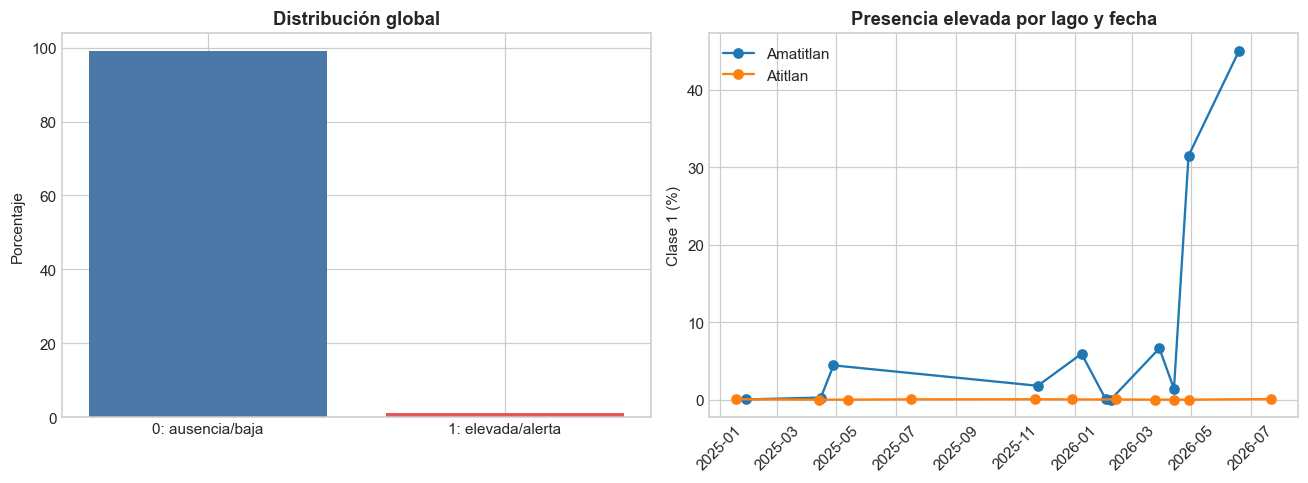

In [10]:
global_respuesta = pd.DataFrame({
    "clase": ["0: ausencia/baja", "1: elevada/alerta"],
    "observaciones": [manifest["n_clase_0"], manifest["n_clase_1"]],
})
global_respuesta["porcentaje"] = 100 * global_respuesta["observaciones"] / global_respuesta["observaciones"].sum()
display(global_respuesta)
display(resumen_lago[["lago", "n_clase_0", "n_clase_1", "pct_clase_1"]])
display(resumen_fecha[["lago", "fecha", "n_clase_0", "n_clase_1", "pct_clase_1"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(global_respuesta["clase"], global_respuesta["porcentaje"], color=["#4C78A8", "#E45756"])
axes[0].set_ylabel("Porcentaje")
axes[0].set_title("Distribución global")
for lago, grupo in resumen_fecha.groupby("lago"):
    axes[1].plot(grupo["fecha"], grupo["pct_clase_1"], marker="o", label=lago.capitalize())
axes[1].set_ylabel("Clase 1 (%)")
axes[1].set_title("Presencia elevada por lago y fecha")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_distribucion_respuesta.png", dpi=180, bbox_inches="tight")
plt.show()


**Interpretación.** El panel izquierdo confirma numéricamente el desbalance ya conocido (~99% clase 0, ~1% clase 1). El panel derecho es más revelador: Atitlán se mantiene esencialmente en 0% de presencia elevada durante toda la serie, mientras que Amatitlán no solo tiene un porcentaje promedio mayor, sino que **escala de forma pronunciada hacia el final del periodo**, de cifras cercanas a 0% a inicios de la serie hasta cerca de 45% de los píxeles en la fecha más reciente.

Esto aporta valor porque muestra que el desbalance no es estático: la proporción de positivos de Amatitlán cambia drásticamente entre fechas, lo que refuerza dos decisiones ya tomadas en el notebook: (a) la recomendación de la sección 2.4 de usar particiones espaciales/temporales en vez de una división aleatoria simple, porque un modelo entrenado mayormente con fechas de baja prevalencia podría no generalizar bien al repunte tardío; y (b) la inclusión de `dias_desde_inicio` como predictor (sección 3.1), que es la única variable capaz de capturar una tendencia de este tipo, casi vertical hacia las últimas fechas.


## 2.4 Desbalance de clases

La razón mayoría:minoría y la exactitud de un clasificador que siempre predice la mayoría permiten dimensionar el problema. Con desbalance severo, *accuracy* deja de ser suficiente: un modelo puede acertar casi todos los píxeles y no detectar ninguna zona de alerta.


In [11]:
n0, n1 = manifest["n_clase_0"], manifest["n_clase_1"]
razon = max(n0, n1) / min(n0, n1)
accuracy_ingenua = 100 * max(n0, n1) / (n0 + n1)
print(f"Razón mayoría:minoría = {razon:.2f}:1")
print(f"Accuracy ingenua (siempre clase 0) = {accuracy_ingenua:.3f}%")
print("Conclusión: desbalance severo." if razon >= 10 else "Conclusión: revisar desbalance.")


Razón mayoría:minoría = 98.41:1
Accuracy ingenua (siempre clase 0) = 98.994%
Conclusión: desbalance severo.


**Consecuencias para los modelos posteriores:** sesgo hacia clase 0, probabilidades mal calibradas y métricas globales engañosas. En el entrenamiento se deberán usar particiones por grupos espaciales/temporales, pesos de clase o remuestreo solo dentro del entrenamiento. La evaluación deberá priorizar *recall* de clase 1, precisión, F1, *balanced accuracy*, PR-AUC y matriz de confusión; ROC-AUC se reportará, pero PR-AUC es más informativa con positivos raros.


**Antecedente (Ejercicio 2).** El análisis exploratorio preliminar, hecho sobre el conjunto de predictores inicial (NDVI/NDWI), ya mostraba el mismo desbalance severo que se confirma aquí con cifras exactas: la clase "alta" es una fracción mínima del total en ambos lagos.

![Balance de clases por lago (Ejercicio 2)](../outputs/ej2_balance_clases_lago.png)


**Interpretación.** En ambos lagos la clase "bajo" domina casi por completo: Atitlán no registra prácticamente ninguna observación fuera de vigilancia, y Amatitlán apenas alcanza ~4% en "moderado" (alerta 1). La categoría "alto" (alerta 2, ≥50 µg/L bajo el marco OMS 2003 usado en este análisis exploratorio) **no aparece en absoluto** en ninguno de los dos lagos.

Esto aporta valor porque anticipa un problema concreto para modelar: si se hubiera usado un umbral tan alto como el de "alerta 2" para definir la respuesta binaria, la clase positiva habría quedado prácticamente vacía y el problema no sería entrenable. Es evidencia de que el umbral de 12 µg/L (alerta 1, OMS 2021) adoptado en la sección 2.1–2.2 es el punto de corte correcto: suficientemente sensible para producir una clase positiva no trivial, sin dejar de ser operativamente relevante.


## 2.5 Auditoría de fuga de información


In [12]:
auditoria = pd.read_csv(resultado["auditoria"])
display(auditoria)
assert VARIABLES_PROHIBIDAS.isdisjoint(PREDICTORES_BASE)


,variable,decision,razon
0,lago,INCLUIR,Predictor base sin uso directo ni indirecto en...
1,fecha,EXCLUIR,"Identificador, variable redundante o no selecc..."
2,fila,EXCLUIR,"Identificador, variable redundante o no selecc..."
3,columna,EXCLUIR,"Identificador, variable redundante o no selecc..."
4,x_utm,INCLUIR,Predictor base sin uso directo ni indirecto en...
5,y_utm,INCLUIR,Predictor base sin uso directo ni indirecto en...
6,b02,EXCLUIR,Fuga: intervino en el valor o en la máscara qu...
7,b03,EXCLUIR,Fuga: intervino en el valor o en la máscara qu...
8,b04,EXCLUIR,Fuga: intervino en el valor o en la máscara qu...
9,b05,EXCLUIR,Fuga: intervino en el valor o en la máscara qu...


La exclusión debe ser más amplia que `chl_cyano`: el valor continuo proviene de NDCI (`B04`, `B05`) y la máscara de agua de la Parte I usa `B02`, `B03`, `B04`, `B08`, `B11`, `B12`, NDVI, NDWI, MNDWI, AWEI y DBSI. Todas esas variables intervinieron directa o indirectamente en la construcción de la etiqueta y se excluyen de `X`.

Se conservan en el dataset para trazabilidad, mapas y auditorías, pero la selección de columnas antes del entrenamiento será explícita. `fila`, `columna`, `fecha` y `nivel_biomasa_oms` tampoco forman parte de `X` por ser identificadores, representación sin transformar o derivación de la respuesta.


# 3. Selección y construcción de variables predictoras

## 3.1 Conjunto predictor propuesto

El conjunto principal es deliberadamente estricto y evita todas las bandas e índices usados en la etiqueta. Para modelos con ambos lagos se usarán las siguientes columnas; en generalización entre lagos se retirará `lago`, y se reportará un análisis de sensibilidad sin coordenadas para medir cuánto depende el desempeño de memorizar ubicación.


In [13]:
tabla_predictores = pd.DataFrame([
    ("b07", "Banda espectral", "Red-edge 3 (~783 nm); puede captar cambios de reflectancia asociados con biomasa y materia suspendida.", "Estandarizar en modelos lineales."),
    ("b8a", "Banda espectral", "NIR estrecha (~865 nm); aporta contraste en agua y floraciones sin usar las bandas del NDCI.", "Estandarizar; revisar colinealidad con B07."),
    ("x_utm", "Espacial", "Posición este en metros; puede representar gradientes locales, entradas y zonas someras.", "Puede memorizar ubicación; validar por bloques."),
    ("y_utm", "Espacial", "Posición norte en metros; complementa los gradientes espaciales.", "Puede memorizar ubicación; validar por bloques."),
    ("sin_dia_anio", "Ingeniería temporal", "Componente seno de la estacionalidad anual.", "Evita la discontinuidad diciembre/enero."),
    ("cos_dia_anio", "Ingeniería temporal", "Componente coseno de la estacionalidad anual.", "Debe usarse junto con el seno."),
    ("dias_desde_inicio", "Ingeniería temporal", "Tendencia temporal desde la primera escena.", "Solo 22 escenas; controlar sobreajuste temporal."),
    ("lago", "Espacial/categórica", "Diferencias estructurales entre Atitlán y Amatitlán.", "Excluir al evaluar transferencia entre lagos."),
    ("nubosidad_pct", "Calidad", "Calidad atmosférica global de la escena.", "Covariable de control; no representa una condición ecológica."),
    ("satelite", "Categórica", "Plataforma Sentinel-2 A/B/C; controla diferencias instrumentales.", "Retirar si induce atajos específicos de fecha."),
], columns=["variable", "tipo", "aporte_potencial", "precaucion"])

assert tabla_predictores["variable"].tolist() == PREDICTORES_BASE
display(tabla_predictores)


,variable,tipo,aporte_potencial,precaucion
0,b07,Banda espectral,Red-edge 3 (~783 nm); puede captar cambios de ...,Estandarizar en modelos lineales.
1,b8a,Banda espectral,NIR estrecha (~865 nm); aporta contraste en ag...,Estandarizar; revisar colinealidad con B07.
2,x_utm,Espacial,Posición este en metros; puede representar gra...,Puede memorizar ubicación; validar por bloques.
3,y_utm,Espacial,Posición norte en metros; complementa los grad...,Puede memorizar ubicación; validar por bloques.
4,sin_dia_anio,Ingeniería temporal,Componente seno de la estacionalidad anual.,Evita la discontinuidad diciembre/enero.
5,cos_dia_anio,Ingeniería temporal,Componente coseno de la estacionalidad anual.,Debe usarse junto con el seno.
6,dias_desde_inicio,Ingeniería temporal,Tendencia temporal desde la primera escena.,Solo 22 escenas; controlar sobreajuste temporal.
7,lago,Espacial/categórica,Diferencias estructurales entre Atitlán y Amat...,Excluir al evaluar transferencia entre lagos.
8,nubosidad_pct,Calidad,Calidad atmosférica global de la escena.,Covariable de control; no representa una condi...
9,satelite,Categórica,Plataforma Sentinel-2 A/B/C; controla diferenc...,Retirar si induce atajos específicos de fecha.


**Antecedente (Ejercicio 2).** La serie temporal exploratoria de NDVI/NDWI/clorofila-a por lago y fecha mostró un aumento de la señal a lo largo de 2026, sobre todo en Amatitlán. Esa tendencia temporal es la motivación directa para incluir `dias_desde_inicio` (y la codificación cíclica `sin_dia_anio`/`cos_dia_anio`) en el conjunto de predictores.

![Serie temporal de NDVI/NDWI/clorofila-a por lago (Ejercicio 2)](../outputs/ej2_serie_temporal_clorofila.png)


**Interpretación.** Amatitlán se mantiene sistemáticamente por encima de Atitlán en clorofila-a promedio a lo largo de toda la serie (de forma consistente entre 4 y 10 µg/L, frente a menos de 2.2 µg/L en Atitlán), y muestra una tendencia ascendente neta hacia el final del periodo, con un salto pronunciado en la última fecha (~2026-06). Atitlán también sube ligeramente hacia abril de 2026, pero a una escala mucho menor y sin sostenerse.

Esto aporta valor de dos maneras: (1) confirma, con una agregación distinta a la de este notebook, la misma asimetría entre lagos que documenta el reporte principal (Amatitlán con floración más establecida que Atitlán); y (2) muestra que la relación con el tiempo no es puramente estacional, hay una deriva de mediano plazo además de las subidas de abril, lo que justifica combinar una variable de tendencia lineal (`dias_desde_inicio`) con la codificación cíclica del día del año (`sin_dia_anio`/`cos_dia_anio`) en el conjunto de predictores, en vez de usar solo una u otra.


## 3.2 Justificación y escenarios de uso

- **Espectrales:** B07 y B8A son las únicas bandas disponibles que no intervinieron en NDCI ni en la máscara de agua de la etiqueta. Se evita construir otro índice con las bandas prohibidas.
- **Espaciales:** `x_utm`/`y_utm` pueden capturar heterogeneidad dentro de los lagos, pero requieren validación espacial estricta; de lo contrario inflan el desempeño.
- **Temporales:** seno/coseno representan estacionalidad y `dias_desde_inicio` una tendencia de largo plazo. La fecha cruda se conserva como identificador, no como número arbitrario.
- **Contexto/calidad:** `lago`, `nubosidad_pct` y `satelite` se incluyen como controles en el modelo mixto, con ablaciones para detectar atajos.

No se agrega una razón B07/B8A al conjunto principal: sería una transformación determinista de dos bandas ya presentes y puede aumentar colinealidad en regresión logística sin demostrar información nueva. Los modelos de árboles podrán capturar interacciones no lineales entre ambas bandas.


**Antecedente (Ejercicio 2).** Los boxplots de NDVI/NDWI por categoría de cianobacteria mostraron que ninguno de los dos índices, por sí solo, separa bien las categorías de biomasa. Ese hallazgo motivó reemplazar los índices precomputados por bandas espectrales crudas (`b07`, `b8a`) como predictores, que le dan a los modelos de árboles más información para encontrar combinaciones no lineales.

![Boxplot NDVI/NDWI por categoría de cianobacteria (Ejercicio 2)](../outputs/ej2_boxplot_ndvi_ndwi_categoria.png)


**Interpretación.** Las distribuciones de NDVI son prácticamente indistinguibles entre "bajo" y "moderado" (misma mediana ≈ -0.05, mismo rango intercuartílico, misma nube densa de valores atípicos hacia -1.0 en ambas categorías). NDWI separa un poco mejor, la mediana de "moderado" es levemente más alta (≈0.45 vs. ≈0.41) y su caja es algo más angosta, pero el solapamiento sigue siendo enorme. Ninguno de los dos índices por sí solo discrimina bien entre categorías, y la clase "alto" ni siquiera tiene datos para comparar.

Esto aporta valor porque es evidencia empírica (no solo intuición) de que resumir el espectro en dos índices ya calculados descarta información útil: un índice colapsa varias bandas en un solo número antes de que el modelo pueda usarlas. Motiva directamente la decisión de la sección 3.1 de pasar a bandas espectrales crudas (`b07`, `b8a`) como predictores, dejando que modelos no lineales (Random Forest, XGBoost) encuentren combinaciones que un índice fijo no puede capturar.


## 3.3 Evaluación preliminar de capacidad predictiva y redundancia


,media_clase_0,media_clase_1,mediana_clase_0,mediana_clase_1,d_estandarizada
b07,1.729891e-02,7.684846e-02,1.040000e-02,6.740000e-02,2.867857
b8a,1.413819e-02,5.218472e-02,8.700000e-03,4.430000e-02,2.166063
nubosidad_pct,1.920327e+00,7.728707e+00,5.400000e-01,4.960000e+00,2.136919
x_utm,7.268654e+05,7.611414e+05,7.012850e+05,7.607450e+05,1.023453
cos_dia_anio,1.331766e-01,-5.420045e-01,5.591689e-02,-4.443783e-01,-0.995009
y_utm,1.613077e+06,1.600561e+06,1.620925e+06,1.601415e+06,-0.960265
dias_desde_inicio,3.026133e+02,4.592363e+02,3.550000e+02,4.650000e+02,0.948069
sin_dia_anio,4.710840e-01,5.139400e-01,6.744437e-01,2.135210e-01,0.080176


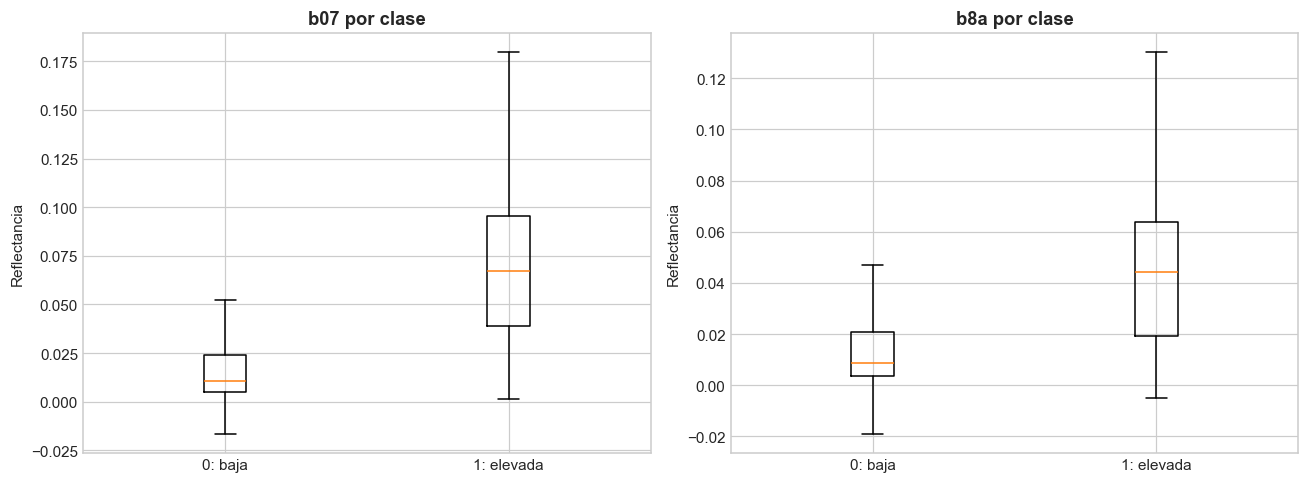

In [14]:
numericos = [c for c in PREDICTORES_BASE if c in muestra.select_dtypes(include="number").columns]

def diferencia_estandarizada(datos, variable, objetivo="alta_cyano"):
    g0 = datos.loc[datos[objetivo] == 0, variable].dropna()
    g1 = datos.loc[datos[objetivo] == 1, variable].dropna()
    var_pooled = ((len(g0) - 1) * g0.var() + (len(g1) - 1) * g1.var()) / max(len(g0) + len(g1) - 2, 1)
    d = (g1.mean() - g0.mean()) / np.sqrt(var_pooled) if var_pooled > 0 else np.nan
    return pd.Series({
        "media_clase_0": g0.mean(), "media_clase_1": g1.mean(),
        "mediana_clase_0": g0.median(), "mediana_clase_1": g1.median(),
        "d_estandarizada": d,
    })

efectos = pd.DataFrame({v: diferencia_estandarizada(muestra, v) for v in numericos}).T
display(efectos.sort_values("d_estandarizada", key=lambda s: s.abs(), ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, variable in zip(axes, ["b07", "b8a"]):
    datos_box = [
        muestra.loc[muestra["alta_cyano"] == clase, variable].to_numpy()
        for clase in [0, 1]
    ]
    ax.boxplot(datos_box, tick_labels=["0: baja", "1: elevada"], showfliers=False)
    ax.set_title(f"{variable} por clase")
    ax.set_ylabel("Reflectancia")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04_bandas_por_clase.png", dpi=180, bbox_inches="tight")
plt.show()


In [15]:
tasas_muestra = []
for variable in ["lago", "satelite"]:
    tabla = muestra.groupby(variable, observed=True)["alta_cyano"].agg(["count", "mean"]).reset_index()
    tabla["pct_clase_1"] = 100 * tabla["mean"]
    tabla["variable"] = variable
    tasas_muestra.append(tabla[["variable", variable, "count", "pct_clase_1"]].rename(columns={variable: "categoria"}))
display(pd.concat(tasas_muestra, ignore_index=True))

print("Estas tasas categóricas son diagnósticas sobre la muestra EDA; los conteos exactos por lago se reportaron en 2.3.")


,variable,categoria,count,pct_clase_1
0,lago,amatitlan,110000,8.884545
1,lago,atitlan,110000,0.025455
2,satelite,Sentinel-2A,40000,11.475000
3,satelite,Sentinel-2B,100000,0.769000
4,satelite,Sentinel-2C,80000,5.552500


Estas tasas categóricas son diagnósticas sobre la muestra EDA; los conteos exactos por lago se reportaron en 2.3.


**Interpretación preliminar.** Una diferencia entre clases no demuestra causalidad ni garantiza generalización. La concentración de positivos en ciertas fechas o en Amatitlán puede hacer que coordenadas, lago, satélite o tendencia funcionen como atajos. Por eso, en el ejercicio 4 se deberá comparar: (a) conjunto completo; (b) sin `lago`, `nubosidad_pct` y `satelite`; y (c) sin coordenadas. La selección final debe basarse en validación espacial/temporal, no solo en asociaciones de esta muestra.


## Comprobaciones finales del avance 1–3


In [16]:
assert manifest["numero_escenas"] == 22
assert manifest["observaciones_totales"] > 0
assert manifest["n_clase_0"] > 0 and manifest["n_clase_1"] > 0
assert resumen_variables["pct_faltantes"].eq(0).all()
assert set(PREDICTORES_BASE).issubset(muestra.columns)
assert VARIABLES_PROHIBIDAS.isdisjoint(PREDICTORES_BASE)
assert muestra[PREDICTORES_BASE].notna().all().all()

print("✓ 22 escenas alineadas")
print(f"✓ {manifest['observaciones_totales']:,} observaciones válidas")
print("✓ Sin valores faltantes en el dataset limpio")
print("✓ Respuesta binaria reproducible con umbral OMS 2021")
print("✓ Predictores presentes y sin fuga conocida")
print("✓ Ejercicios 1, 2 y 3 listos")


✓ 22 escenas alineadas
✓ 13,689,403 observaciones válidas
✓ Sin valores faltantes en el dataset limpio
✓ Respuesta binaria reproducible con umbral OMS 2021
✓ Predictores presentes y sin fuga conocida
✓ Ejercicios 1, 2 y 3 listos
